In [ ]:
# Создай цикл, который рандомизирует theta_E (от 0.5 до 2.0) и center_x/y (от -0.2 до 0.2).

/tmp/ipykernel_528566/363215730.py:65: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(result + 1e-3), origin='lower', cmap='inferno')


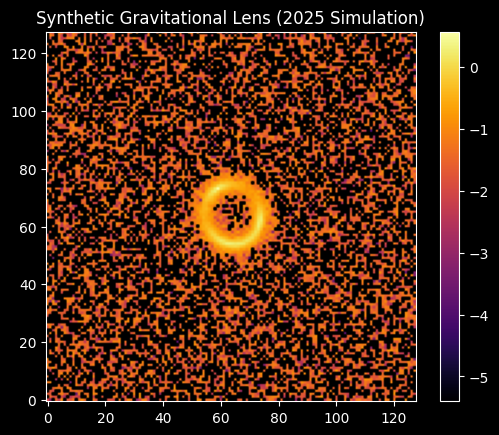

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.psf import PSF
import torch # Если захочешь сразу гнать в тензоры

def generate_lens_image(theta_E, x_center, y_center, e1=0.1, e2=0.1):
    """
    Генерирует изображение гравитационного линзирования.
    theta_E: радиус Эйнштейна (масса линзы)
    x_center, y_center: координаты центра черной дыры
    """
    # 1. Настройка сетки пикселей (наше "окно" в космос)
    num_pix = 128
    delta_pix = 0.05 # размер пикселя в угловых секундах
    
    # Создаем систему координат
    ra_at_xy_0, dec_at_xy_0 = -delta_pix * num_pix / 2, -delta_pix * num_pix / 2
    transform_pix2angle = np.array([[delta_pix, 0], [0, delta_pix]])
    
    kwargs_grid = {
        'ra_at_xy_0': ra_at_xy_0, 'dec_at_xy_0': dec_at_xy_0,
        'transform_pix2angle': transform_pix2angle,
        'nx': num_pix, 'ny': num_pix
    }
    pixel_grid = PixelGrid(**kwargs_grid)
    psf_class = PSF(psf_type='NONE')

    # 2. Модель Линзы (Черная дыра / Галактика)
    # Используем SIE (Singular Isothermal Ellipsoid) - стандарт в астрофизике
    lens_model_list = ['SIE']
    lens_model_class = LensModel(lens_model_list=lens_model_list)
    kwargs_sie = {'theta_E': theta_E, 'e1': e1, 'e2': e2, 'center_x': x_center, 'center_y': y_center}
    kwargs_lens = [kwargs_sie]

    # 3. Модель Источника (Далекая галактика, которую линзируют)
    # SERSIC - стандартный профиль яркости галактик
    source_model_list = ['SERSIC']
    source_model_class = LightModel(light_model_list=source_model_list)
    kwargs_sersic = {'amp': 100, 'R_sersic': 0.1, 'n_sersic': 2, 'center_x': 0, 'center_y': 0}
    kwargs_source = [kwargs_sersic]

    # 4. Рендеринг изображения
    imageModel = ImageModel(psf_class=psf_class,
        data_class=pixel_grid, lens_model_class=lens_model_class,
                            source_model_class=source_model_class)
    
    image = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source)
    
    # Добавляем немного космического шума (Пуассоновский шум)
    exp_time = 100
    background_rms = 0.05
    noise = np.random.normal(0, background_rms, size=image.shape)
    image_with_noise = image + noise

    return image_with_noise

# --- Тестовый запуск ---
# Генерируем "идеальное" кольцо
result = generate_lens_image(theta_E=0.5, x_center=0.05, y_center=-0.05)

plt.imshow(np.log10(result + 1e-3), origin='lower', cmap='inferno')
plt.title("Synthetic Gravitational Lens (2025 Simulation)")
plt.colorbar()
plt.show()
